# Binning

In [37]:
# ============================================
# Import Libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [38]:
# ============================================
# Load Dataset
# ============================================

df = pd.read_csv(r"C:\Users\divya\OneDrive\DS\EDA\train.csv",usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [39]:
# ============================================
# Remove Missing Values
# ============================================

df.dropna(inplace=True)

df.shape

(714, 3)

In [40]:
# ============================================
# Features and Target
# ============================================

X = df.iloc[:,1:]
y = df.iloc[:,0]

In [41]:
# ============================================
# Train Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [42]:
# ============================================
# Decision Tree Without Binning
# ============================================

clf = DecisionTreeClassifier()

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy_score(y_test, y_pred)

0.6293706293706294

In [43]:
# ============================================
# Cross Validation Without Binning
# ============================================

np.mean(
    cross_val_score(
        DecisionTreeClassifier(),
        X,
        y,
        cv=10,
        scoring='accuracy'
    )
)

np.float64(0.6303012519561816)

In [44]:
# ============================================
# Create KBinsDiscretizer
# ============================================

kbin_age = KBinsDiscretizer(
    n_bins=10,
    encode='ordinal',
    strategy='quantile'
)

kbin_fare = KBinsDiscretizer(
    n_bins=10,
    encode='ordinal',
    strategy='quantile'
)

In [45]:
# ============================================
# Column Transformer
# ============================================

trf = ColumnTransformer([
    ('first', kbin_age, [0]),
    ('second', kbin_fare, [1])
])

In [46]:
# ============================================
# Transform Data
# ============================================

X_train_trf = trf.fit_transform(X_train)

X_test_trf = trf.transform(X_test)

C:\Users\divya\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\divya\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


In [47]:
# ============================================
# Age Bin Edges
# ============================================

trf.named_transformers_['first'].bin_edges_

array([array([ 0.42, 14.  , 19.  , 22.  , 25.  , 28.5 , 32.  , 36.  , 42.  ,
              50.  , 80.  ])                                                ],
      dtype=object)

In [48]:
# ============================================
# Fare Bin Edges
# ============================================

trf.named_transformers_['second'].bin_edges_

array([array([  0.    ,   7.75  ,   7.8958,   9.225 ,  13.    ,  15.75  ,
               26.    ,  29.125 ,  51.4792,  82.1708, 512.3292])         ],
      dtype=object)

In [49]:
# ============================================
# Create Output DataFrame
# ============================================

output = pd.DataFrame({

    'age': X_train['Age'],
    'age_trf': X_train_trf[:,0],

    'fare': X_train['Fare'],
    'fare_trf': X_train_trf[:,1]

})

output.sample(5)

,age,age_trf,fare,fare_trf
326,61.0,9.0,6.2375,0.0
265,36.0,7.0,10.5000,3.0
434,50.0,9.0,55.9000,8.0
658,23.0,3.0,13.0000,4.0
537,30.0,5.0,106.4250,9.0


In [50]:
# ============================================
# Decision Tree After Binning
# ============================================

clf = DecisionTreeClassifier()

clf.fit(X_train_trf, y_train)

y_pred2 = clf.predict(X_test_trf)

accuracy_score(y_test, y_pred2)

0.6223776223776224

In [51]:
# ============================================
# Cross Validation After Binning
# ============================================

X_trf = trf.fit_transform(X)

np.mean(
    cross_val_score(
        DecisionTreeClassifier(),
        X_trf,
        y,
        cv=10,
        scoring='accuracy'
    )
)

C:\Users\divya\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\divya\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


np.float64(0.682140062597809)

In [52]:
# ============================================
# Create Function
# ============================================

def discretize(bins, strategy):

    kbin_age = KBinsDiscretizer(
        n_bins=bins,
        encode='ordinal',
        strategy=strategy
    )

    kbin_fare = KBinsDiscretizer(
        n_bins=bins,
        encode='ordinal',
        strategy=strategy
    )

    trf = ColumnTransformer([
        ('first', kbin_age, [0]),
        ('second', kbin_fare, [1])
    ])

    X_trf = trf.fit_transform(X)

    print(
        np.mean(
            cross_val_score(
                DecisionTreeClassifier(),
                X_trf,
                y,
                cv=10,
                scoring='accuracy'
            )
        )
    )

    # ====================================
    # Age Plot
    # ====================================

    plt.figure(figsize=(14,4))

    plt.subplot(121)

    plt.hist(X['Age'])

    plt.title("Age Before")

    plt.subplot(122)

    plt.hist(X_trf[:,0], color='red')

    plt.title("Age After")

    plt.show()

    # ====================================
    # Fare Plot
    # ====================================

    plt.figure(figsize=(14,4))

    plt.subplot(121)

    plt.hist(X['Fare'])

    plt.title("Fare Before")

    plt.subplot(122)

    plt.hist(X_trf[:,1], color='red')

    plt.title("Fare After")

    plt.show()

C:\Users\divya\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\divya\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


0.6723004694835681


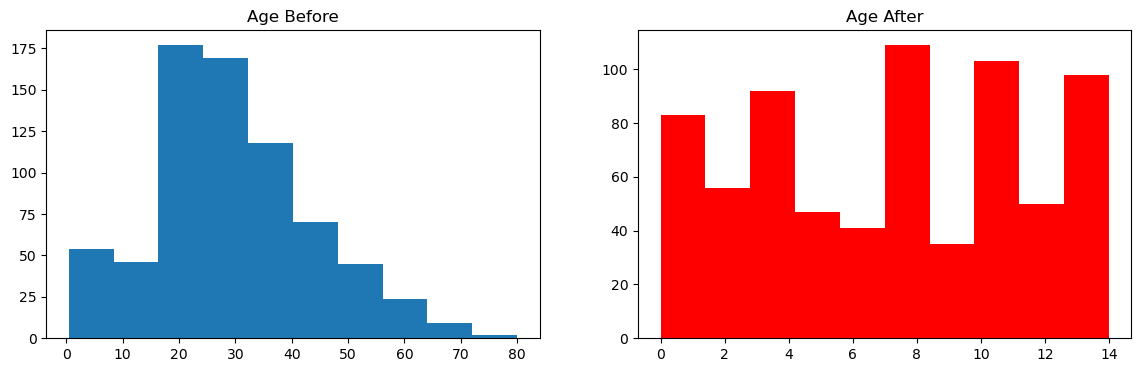

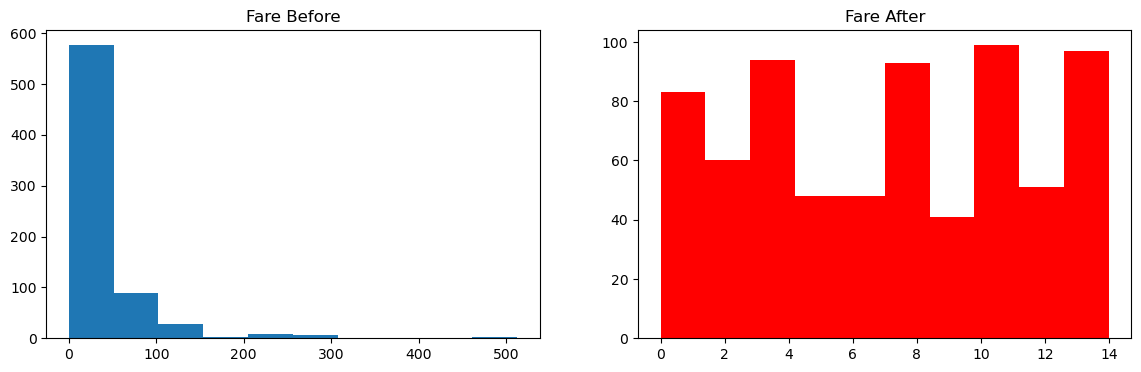

In [53]:
# ============================================
# Call Function
# ============================================

discretize(15, 'quantile')

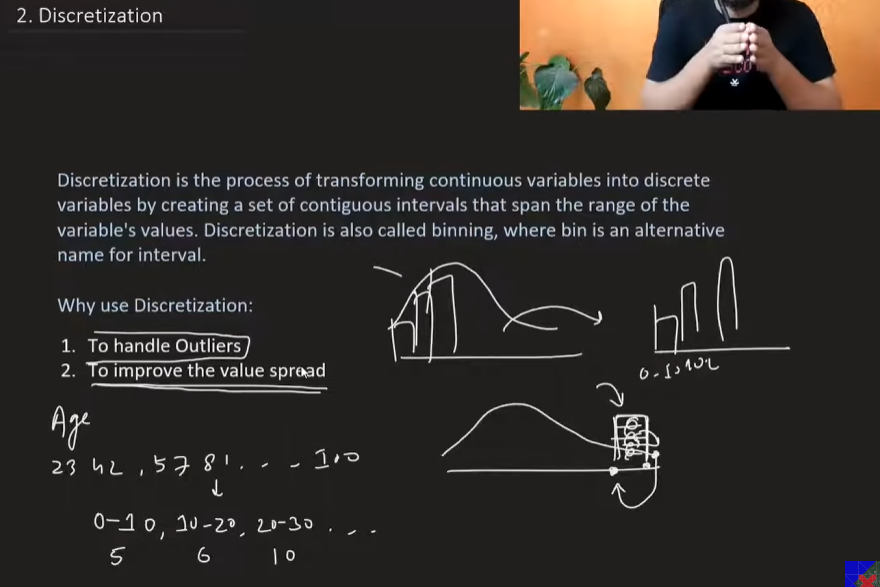

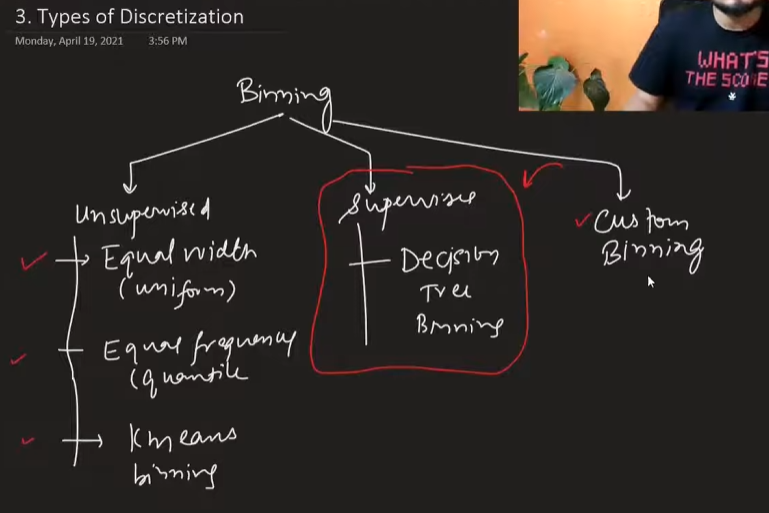

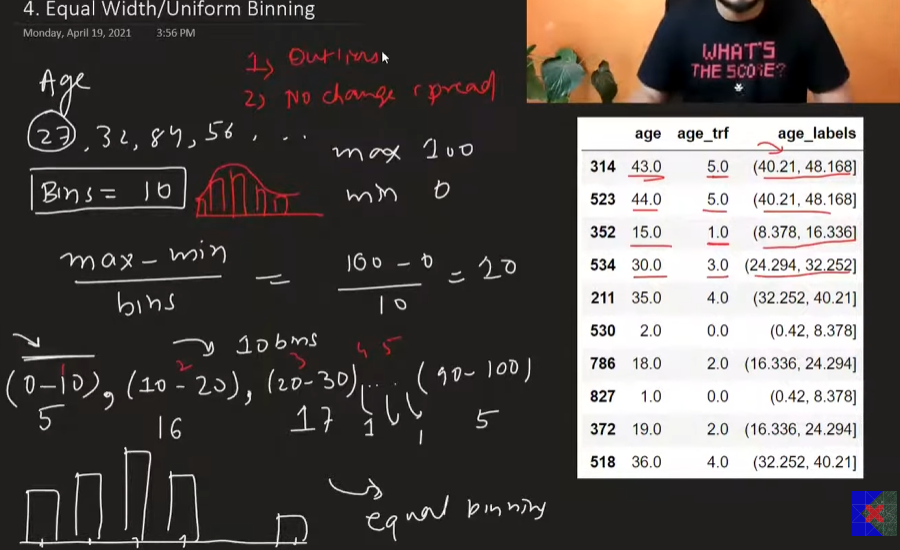

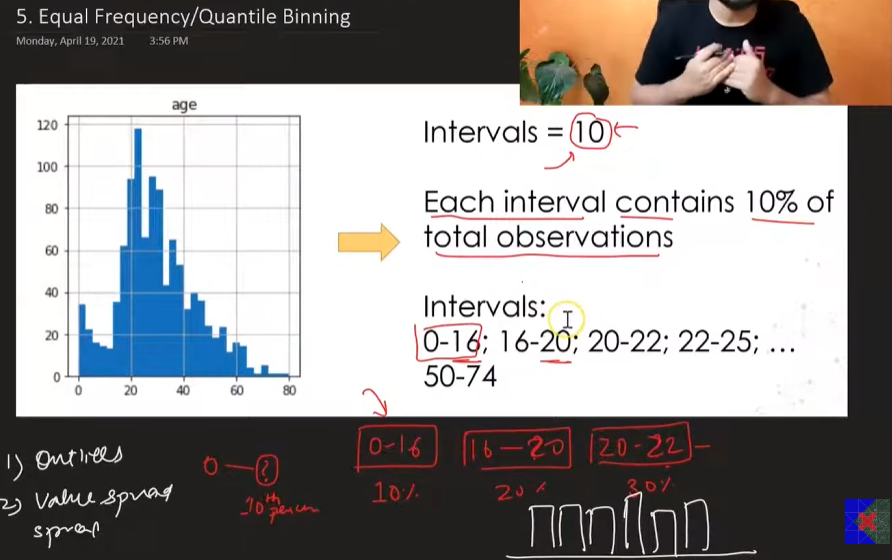

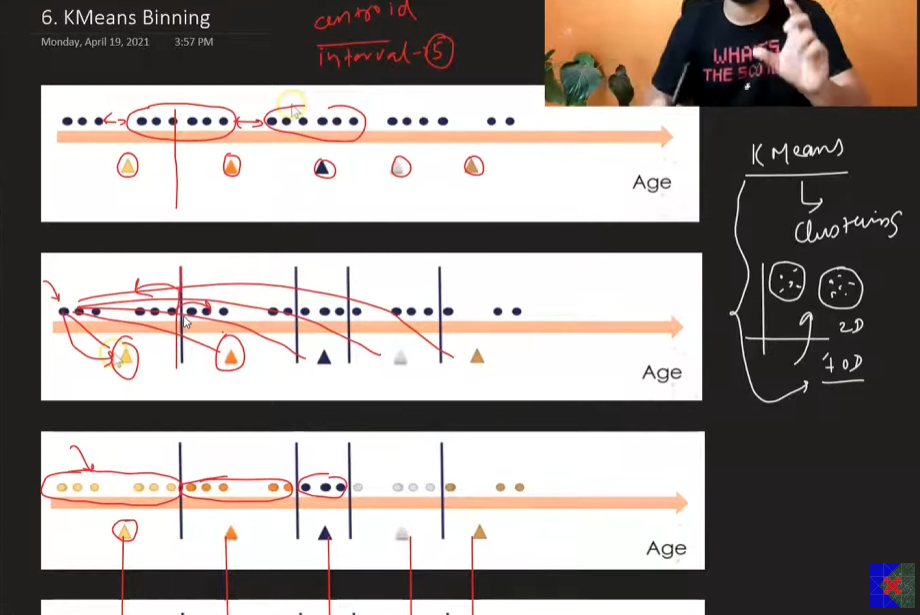

# Binarization

In [55]:
df = pd.read_csv(r"C:\Users\divya\OneDrive\DS\EDA\train.csv",usecols=['Age','Fare','Survived','SibSp','Parch'])
df.head()

,Survived,Age,SibSp,Parch,Fare
0,0,22.0,1,0,7.2500
1,1,38.0,1,0,71.2833
2,1,26.0,0,0,7.9250
3,1,35.0,1,0,53.1000
4,0,35.0,0,0,8.0500


In [56]:
df.dropna(inplace=True)

In [57]:
df['family'] = df['SibSp'] + df['Parch']

In [58]:
df.drop(columns=['SibSp','Parch'],inplace=True)

In [59]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [60]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [61]:
X_train.head()

,Age,Fare,family
328,31.0,20.5250,2
73,26.0,14.4542,1
253,30.0,16.1000,1
719,33.0,7.7750,0
666,25.0,13.0000,0


In [62]:
# Without binarization

clf = DecisionTreeClassifier()

clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)

accuracy_score(y_test,y_pred)

0.6223776223776224

In [63]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6443075117370893)

In [64]:
# Applying Binarization

from sklearn.preprocessing import Binarizer


trf = ColumnTransformer([
    ('bin',Binarizer(copy=False),['family'])
],remainder='passthrough')


X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

pd.DataFrame(X_train_trf,columns=['family','Age','Fare'])

,family,Age,Fare
0,1.0,31.0,20.5250
1,1.0,26.0,14.4542
2,1.0,30.0,16.1000
3,0.0,33.0,7.7750
4,0.0,25.0,13.0000
...,...,...,...
566,1.0,46.0,61.1750
567,0.0,25.0,13.0000
568,0.0,41.0,134.5000
569,1.0,33.0,20.5250


In [65]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

accuracy_score(y_test,y_pred2)

0.6013986013986014

In [66]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X_trf,y,cv=10,scoring='accuracy'))

np.float64(0.6303794992175273)

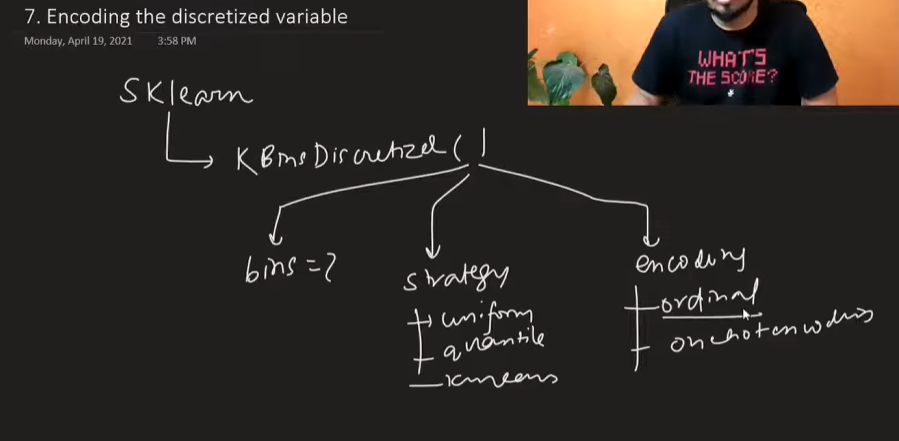

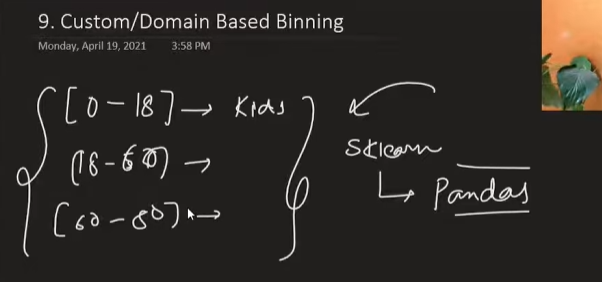